<a href="https://colab.research.google.com/github/sandydiamantino/retailrocket-topsis/blob/main/retailrocket_topsis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Benchmark de Recomendação com Grafo e TOPSIS

Este notebook apresenta um experimento inicial de recomendação de produtos
utilizando o dataset Retailrocket.

O objetivo é comparar:

1. Uma ordenação simples dos produtos candidatos.
2. Uma ordenação multicritério utilizando o método TOPSIS.

## Etapa 1: Análise Exploratória dos Dados

Nesta etapa será realizada a análise exploratória dos dados.

### Importando as bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_theme(style='whitegrid')

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


### Definindo os links Raw

In [2]:
EVENTS_URL = (
    'https://raw.githubusercontent.com/sandydiamantino/retailrocket-topsis/refs/heads/main/data/sample_events.csv'
)

PROPERTIES_URL = (
    'https://raw.githubusercontent.com/sandydiamantino/retailrocket-topsis/refs/heads/main/data/sample_item_properties.csv'
)

print('Links definidos.')

Links definidos.


### Testando os links Raw

In [3]:
import requests

urls = {
    'events': EVENTS_URL,
    'properties': PROPERTIES_URL
}

for name, url in urls.items():
    response = requests.get(url)

    print(f'{name}: status HTTP {response.status_code}')

    if response.status_code == 200:
        print('  Link acessível.')
    else:
        print('  Verifique o link, o nome do arquivo ou a visibilidade do repositório.')

events: status HTTP 200
  Link acessível.
properties: status HTTP 200
  Link acessível.


### Carregando os arquivos

In [4]:
events = pd.read_csv(EVENTS_URL)

properties = pd.read_csv(PROPERTIES_URL)

print('Arquivos carregados com sucesso.')

Arquivos carregados com sucesso.


### Verificando o tamanho das tabelas

In [5]:
print('Tabela de eventos:')
print(f'Linhas: {events.shape[0]:,}')
print(f'Colunas: {events.shape[1]}')

print('\nTabela de propriedades:')
print(f'Linhas: {properties.shape[0]:,}')
print(f'Colunas: {properties.shape[1]}')

Tabela de eventos:
Linhas: 9,385
Colunas: 6

Tabela de propriedades:
Linhas: 392,648
Colunas: 4


### Visualizando as primeiras linhas

In [6]:
# Os eventos
display(events.head())

,timestamp,visitorid,event,itemid,transactionid,datetime
0,1433193132535,1134473,view,396045,NaN,2015-06-01 21:12:12.535
1,1433194696771,1314862,view,344224,NaN,2015-06-01 21:38:16.771
2,1433220848630,467124,view,396318,NaN,2015-06-02 04:54:08.630
3,1433218109710,1121229,view,370889,NaN,2015-06-02 04:08:29.710
4,1433178802896,39027,view,26210,NaN,2015-06-01 17:13:22.896


In [7]:
# As propriedades
display(properties.head())

,timestamp,itemid,property,value
0,1431831600000,156781,917,828513
1,1433646000000,272201,790,n10320.000
2,1440298800000,368230,400,1297729 n720.000 1178208 n900.000 424566
3,1431831600000,329408,888,1333963 747375 927741 1071593 547687 199524
4,1431831600000,103584,790,n459360.000


### Verificando os nomes das colunas

In [8]:
print('Colunas da tabela de eventos:')
print(events.columns.tolist())

print('\nColunas da tabela de propriedades:')
print(properties.columns.tolist())

Colunas da tabela de eventos:
['timestamp', 'visitorid', 'event', 'itemid', 'transactionid', 'datetime']

Colunas da tabela de propriedades:
['timestamp', 'itemid', 'property', 'value']


### Verificando os tipos das colunas

In [9]:
print('Tipos das colunas de eventos:')
display(events.dtypes.to_frame('tipo'))

print('Tipos das colunas de propriedades:')
display(properties.dtypes.to_frame('tipo'))

Tipos das colunas de eventos:


,tipo
timestamp,int64
visitorid,int64
event,object
itemid,int64
transactionid,float64
datetime,object


Tipos das colunas de propriedades:


,tipo
timestamp,int64
itemid,int64
property,object
value,object


### Garantindo a coluna de data

In [10]:
if 'datetime' not in events.columns:
    events['datetime'] = pd.to_datetime(
        events['timestamp'],
        unit='ms'
    )
else:
    events['datetime'] = pd.to_datetime(
        events['datetime'],
        errors='coerce'
    )

print(events['datetime'].dtype)
display(events[['timestamp', 'datetime']].head())

datetime64[ns]


,timestamp,datetime
0,1433193132535,2015-06-01 21:12:12.535
1,1433194696771,2015-06-01 21:38:16.771
2,1433220848630,2015-06-02 04:54:08.630
3,1433218109710,2015-06-02 04:08:29.710
4,1433178802896,2015-06-01 17:13:22.896


### Verificando valores ausentes

In [11]:
# Para eventos
missing_events = (
    events.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame('quantidade')
)

display(missing_events)

,quantidade
transactionid,9339
timestamp,0
visitorid,0
event,0
itemid,0
datetime,0


In [12]:
# Para propriedades
missing_properties = (
    properties.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame('quantidade')
)

display(missing_properties)

,quantidade
timestamp,0
itemid,0
property,0
value,0


### Contando os tipos e calculando o percentual de cada evento

In [13]:
# Contando os tipos de eventos
event_counts = (
    events['event']
    .value_counts()
    .rename_axis('tipo_evento')
    .reset_index(name='quantidade')
)

display(event_counts)

# Calculando o percentual de cada evento
event_percentages = (
    events['event']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis('tipo_evento')
    .reset_index(name='percentual')
)

display(event_percentages)

,tipo_evento,quantidade
0,view,9076
1,addtocart,263
2,transaction,46


,tipo_evento,percentual
0,view,96.71
1,addtocart,2.80
2,transaction,0.49


### Gráficos: Eventos

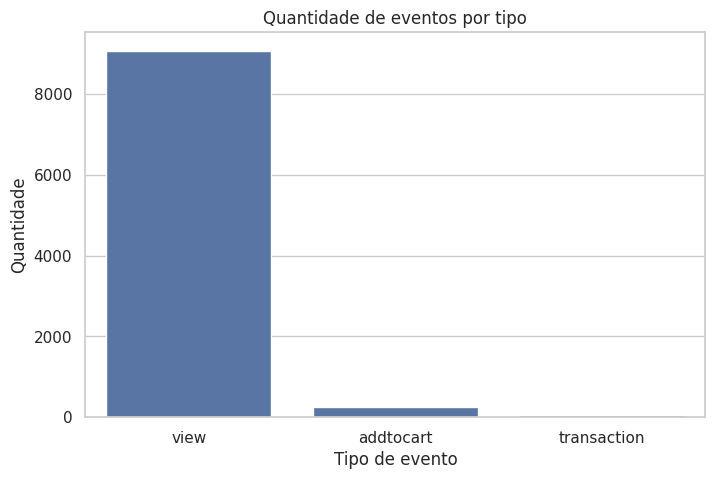

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=events,
    x='event',
    order=events['event'].value_counts().index
)

plt.title('Quantidade de eventos por tipo')
plt.xlabel('Tipo de evento')
plt.ylabel('Quantidade')

plt.show()

### Visitantes / Produto

In [15]:
summary = pd.DataFrame({
    'indicador': [
        'Eventos',
        'Visitantes únicos',
        'Produtos únicos',
        'Transações identificadas'
    ],
    'quantidade': [
        len(events),
        events['visitorid'].nunique(),
        events['itemid'].nunique(),
        events['transactionid'].notna().sum()
    ]
})

display(summary)

,indicador,quantidade
0,Eventos,9385
1,Visitantes únicos,5000
2,Produtos únicos,6610
3,Transações identificadas,46


### Visitantes / Tipo de Evento

In [16]:
visitors_by_event = (
    events.groupby('event')['visitorid']
    .nunique()
    .sort_values(ascending=False)
    .rename('visitantes_unicos')
    .to_frame()
)

display(visitors_by_event)

,visitantes_unicos
event,
view,4991
addtocart,145
transaction,39


### Produtos / Tipo de Interação

In [25]:
products_by_event = (
    events.groupby('event')['itemid']
    .nunique()
    .sort_values(ascending=False)
    .rename('produtos_unicos')
    .to_frame()
)

display(products_by_event)

,produtos_unicos
event,
view,6564
addtocart,225
transaction,46


### Período dos dados

In [18]:
print('Primeiro evento:')
print(events['datetime'].min())

print('\nÚltimo evento:')
print(events['datetime'].max())

Primeiro evento:
2015-05-03 03:02:00.563000

Último evento:
2015-09-18 01:16:53.281000


In [19]:
# Quanto eventos ocorreram por dia
events_by_day = (
    events
    .set_index('datetime')
    .resample('D')
    .size()
    .rename('quantidade_eventos')
)

display(events_by_day.head())

,quantidade_eventos
datetime,
2015-05-03,24
2015-05-04,60
2015-05-05,67
2015-05-06,87
2015-05-07,123


### Gráfico: Eventos ao longo do tempo

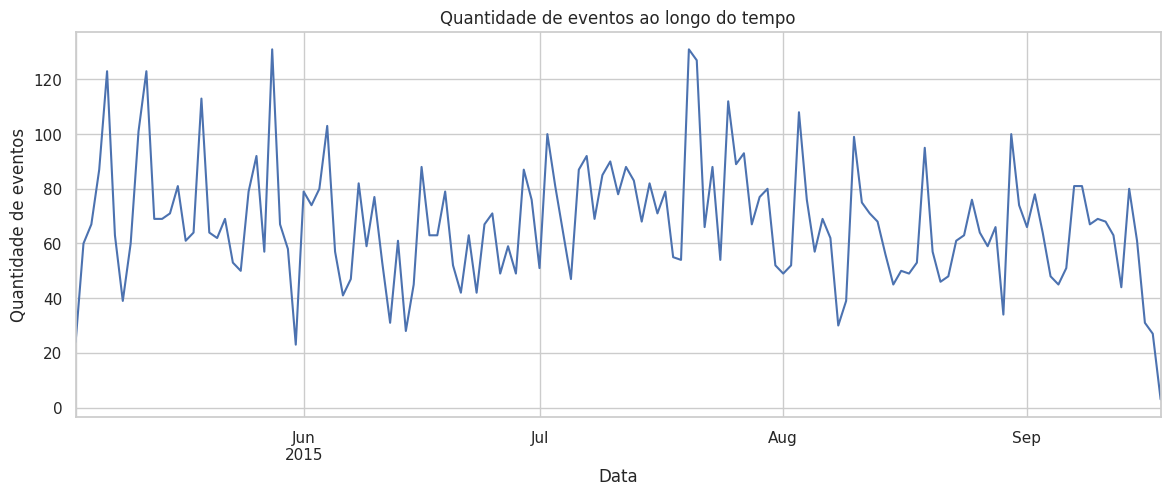

In [20]:
plt.figure(figsize=(14, 5))

events_by_day.plot()

plt.title('Quantidade de eventos ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Quantidade de eventos')

plt.show()

### Separando as transações

In [21]:
transactions = events[
    events['event'] == 'transaction'
].copy()

print('Eventos de compra:', len(transactions))
print('Visitantes que compraram:', transactions['visitorid'].nunique())
print('Produtos comprados:', transactions['itemid'].nunique())

display(transactions.head())

Eventos de compra: 46
Visitantes que compraram: 39
Produtos comprados: 46


,timestamp,visitorid,event,itemid,transactionid,datetime
241,1433440854985,1207981,transaction,350734,8693.0,2015-06-04 18:00:54.985
324,1433446155080,763580,transaction,257115,15026.0,2015-06-04 19:29:15.080
484,1433748335994,766502,transaction,414995,10859.0,2015-06-08 07:25:35.994
488,1433787533953,293600,transaction,55044,3462.0,2015-06-08 18:18:53.953
612,1433976818104,343404,transaction,44220,16824.0,2015-06-10 22:53:38.104


### Produtos mais visualizados

In [22]:
most_viewed = (
    events[events['event'] == 'view']
    .groupby('itemid')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename('visualizacoes')
    .to_frame()
)

display(most_viewed)

,visualizacoes
itemid,
153401,33
95489,30
447661,19
212583,18
322920,14
461686,12
187946,11
20407,11
234255,10


### Produtos mais comprados

,compras
itemid,
698,1
18171,1
20407,1
22145,1
36290,1
44220,1
50684,1
55044,1
76426,1


<Figure size 1200x500 with 0 Axes>

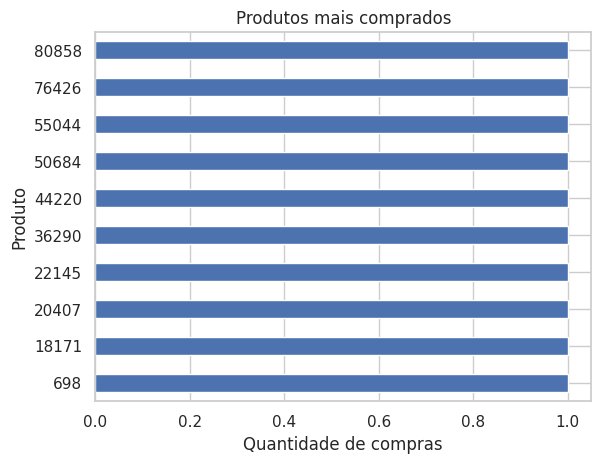

In [26]:
most_purchased = (
    transactions
    .groupby('itemid')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename('compras')
    .to_frame()
)

display(most_purchased)

# Gráfico
plt.figure(figsize=(12, 5))

most_purchased.sort_values('compras').plot(
    kind='barh',
    legend=False
)

plt.title('Produtos mais comprados')
plt.xlabel('Quantidade de compras')
plt.ylabel('Produto')

plt.show()

### Eventos / Visitante

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    events_per_visitor,
    bins=30,
    kde=False
)

plt.title('Distribuição da quantidade de eventos por visitante')
plt.xlabel('Quantidade de eventos')
plt.ylabel('Quantidade de visitantes')

plt.show()

NameError: name 'events_per_visitor' is not defined

<Figure size 1000x500 with 0 Axes>

### Taxa simples de conversão por produto

In [ ]:
views_by_item = (
    events[events['event'] == 'view']
    .groupby('itemid')
    .size()
    .rename('visualizacoes')
)

transactions_by_item = (
    events[events['event'] == 'transaction']
    .groupby('itemid')
    .size()
    .rename('transacoes')
)

item_statistics = pd.concat(
    [views_by_item, transactions_by_item],
    axis=1
).fillna(0)

item_statistics['taxa_conversao'] = (
    item_statistics['transacoes'] /
    item_statistics['visualizacoes'].clip(lower=1)
)

item_statistics = item_statistics.sort_values(
    'taxa_conversao',
    ascending=False
)

display(item_statistics.head(10))

### Salvando os resultados

In [ ]:
event_counts.to_csv(
    '/content/event_counts.csv',
    index=False
)

summary.to_csv(
    '/content/dataset_summary.csv',
    index=False
)

item_statistics.to_csv(
    '/content/item_statistics.csv'
)

print('Tabelas exploratórias salvas em /content.')